# Assignment 2 - Unit 3: K-Nearest Neighbours

**Name:** Adarsh Pandey
**Roll No.:** 14
**Subject:** Machine Learning
**Department:** Computer Science, Gujarat University - MSc AIML-2

## Practical Question 1(a) - KNN From Scratch on Iris Dataset

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def knn_scratch(X_tr, y_tr, x, k=3):
    dists = np.sqrt(np.sum((X_tr - x) ** 2, axis=1))
    return np.bincount(y_tr[np.argsort(dists)[:k]]).argmax()

y_pred = np.array([knn_scratch(X_train, y_train, x) for x in X_test])
acc = np.mean(y_pred == y_test)

print(f"Accuracy (From Scratch, k=3): {acc:.4f}")
print(f"Correct: {np.sum(y_pred == y_test)} / {len(y_test)}")
print(f"\nActual   : {y_test}")
print(f"Predicted: {y_pred}")

Accuracy (From Scratch, k=3): 1.0000
Correct: 30 / 30

Actual   : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Predicted: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## Practical Question 1(b) - KNN using sklearn KNeighborsClassifier

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy  (sklearn, k=3): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (sklearn, k=3): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall    (sklearn, k=3): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score  (sklearn, k=3): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=iris.target_names)}")

Accuracy  (sklearn, k=3): 1.0000
Precision (sklearn, k=3): 1.0000
Recall    (sklearn, k=3): 1.0000
F1 Score  (sklearn, k=3): 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Practical Question 1(c) - Error Rate for k = 1 to 10

  k    Accuracy  Error Rate
----------------------------
  1      1.0000      0.0000
  2      1.0000      0.0000
  3      1.0000      0.0000
  4      1.0000      0.0000
  5      1.0000      0.0000
  6      1.0000      0.0000
  7      0.9667      0.0333
  8      1.0000      0.0000
  9      1.0000      0.0000
 10      1.0000      0.0000


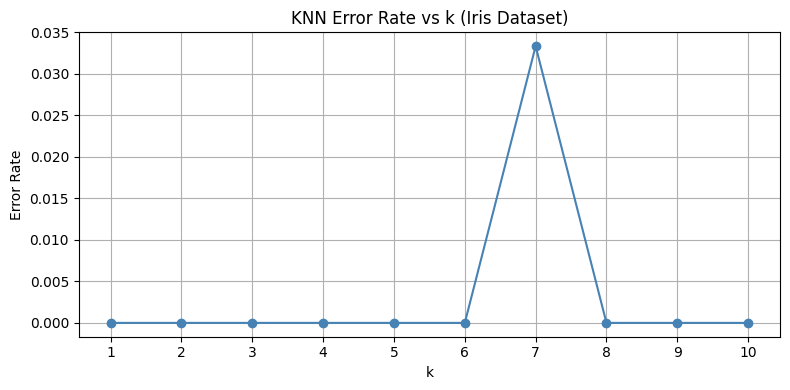

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

errors = []
print(f"{'k':>3}  {'Accuracy':>10}  {'Error Rate':>10}")
print("-" * 28)
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    err = 1 - acc
    errors.append(err)
    print(f"{k:>3}  {acc:>10.4f}  {err:>10.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), errors, marker='o', color='steelblue')
plt.xlabel('k')
plt.ylabel('Error Rate')
plt.title('KNN Error Rate vs k (Iris Dataset)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()